In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-spending-patterns/shopping_behavior_updated.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/customer-spending-patterns/shopping_behavior_updated.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
categorical_cols = [
    "Gender","Category","Location","Size","Color","Season",
    "Subscription Status","Shipping Type","Discount Applied",
    "Promo Code Used","Payment Method","Frequency of Purchases"
]

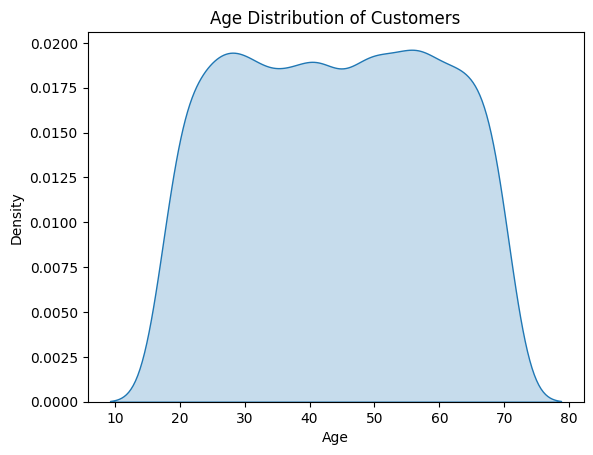

In [7]:
plt.figure()
sns.kdeplot(df["Age"], fill=True)
plt.title("Age Distribution of Customers")
plt.show()


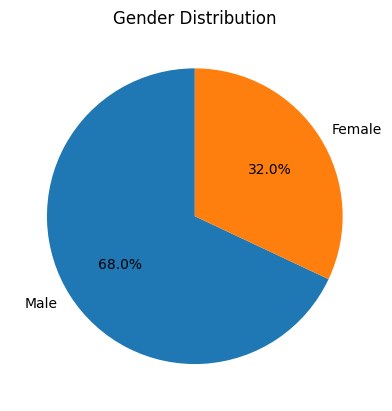

In [8]:
plt.figure()
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()


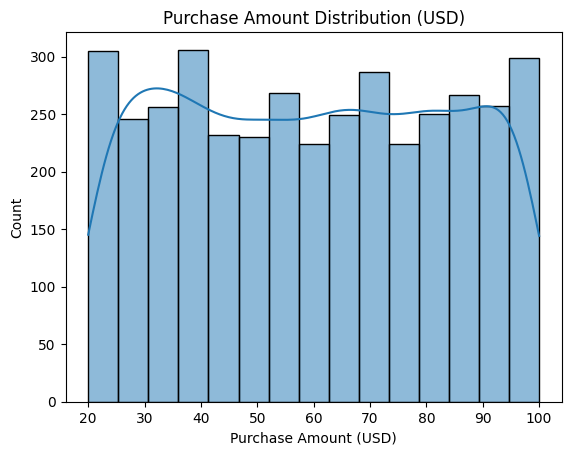

In [9]:
plt.figure()
sns.histplot(df["Purchase Amount (USD)"], kde=True)
plt.title("Purchase Amount Distribution (USD)")
plt.show()


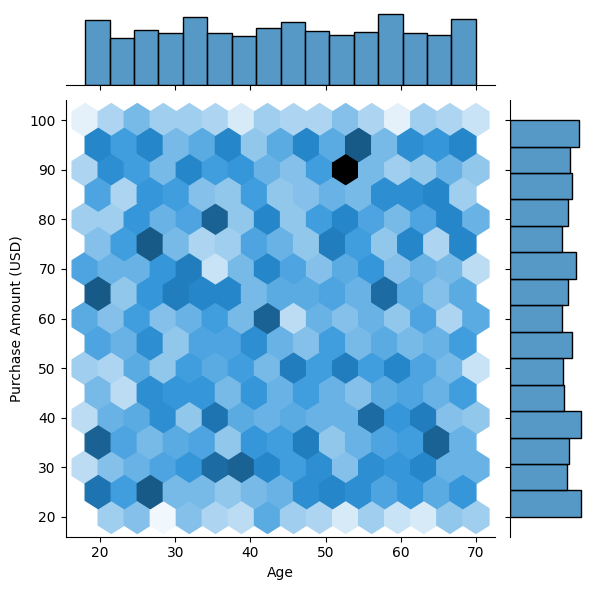

In [10]:
sns.jointplot(
    data=df,
    x="Age",
    y="Purchase Amount (USD)",
    kind="hex"
)
plt.show()

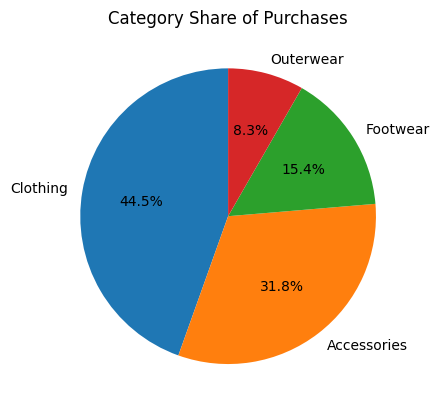

In [11]:
plt.figure()
df["Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Category Share of Purchases")
plt.show()


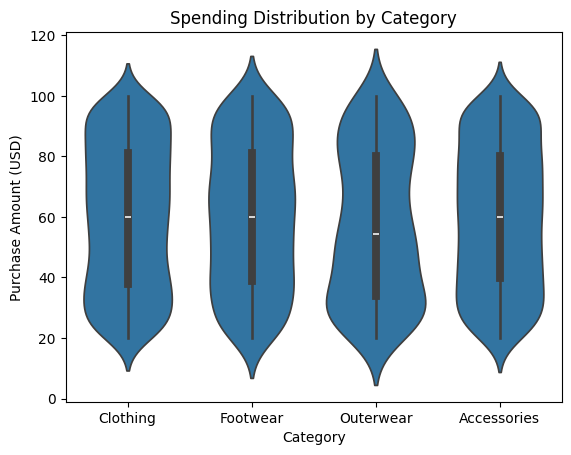

In [12]:
plt.figure()
sns.violinplot(
    x="Category",
    y="Purchase Amount (USD)",
    data=df
)
plt.title("Spending Distribution by Category")
plt.show()


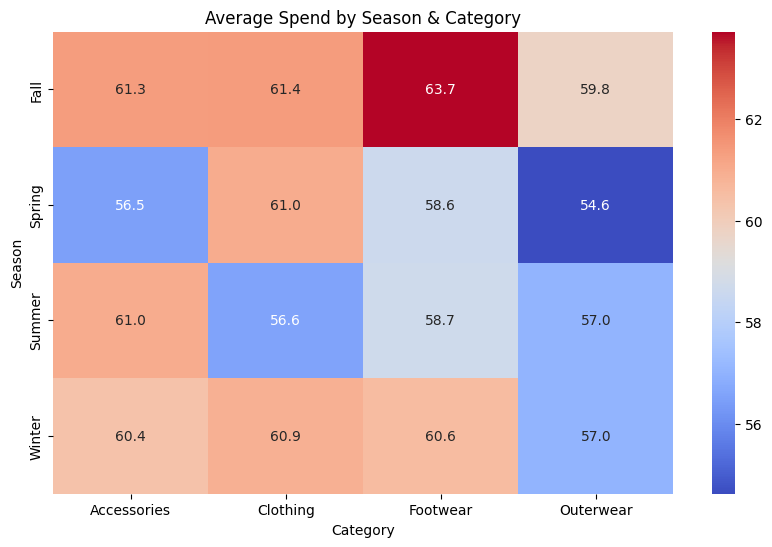

In [13]:
season_category = pd.crosstab(
    df["Season"],
    df["Category"],
    values=df["Purchase Amount (USD)"],
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(
    season_category,
    cmap="coolwarm",
    annot=True,
    fmt=".1f"
)
plt.title("Average Spend by Season & Category")
plt.show()


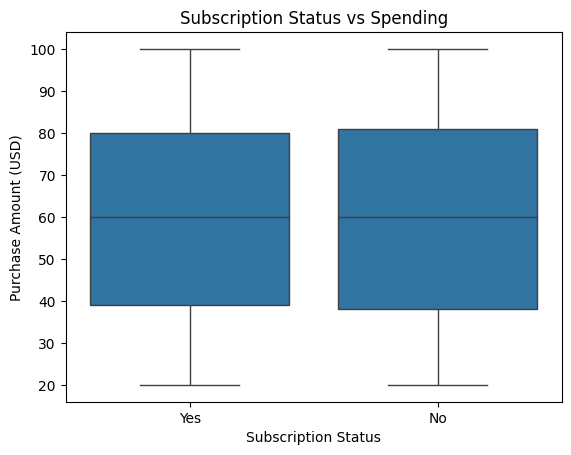

In [14]:
plt.figure()
sns.boxplot(
    x="Subscription Status",
    y="Purchase Amount (USD)",
    data=df
)
plt.title("Subscription Status vs Spending")
plt.show()


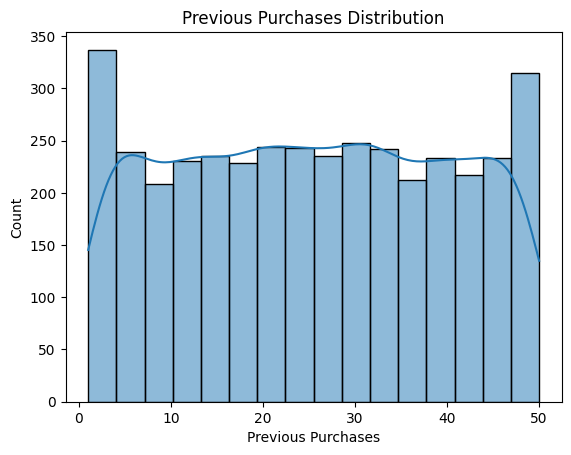

In [15]:
plt.figure()
sns.histplot(df["Previous Purchases"], kde=True)
plt.title("Previous Purchases Distribution")
plt.show()


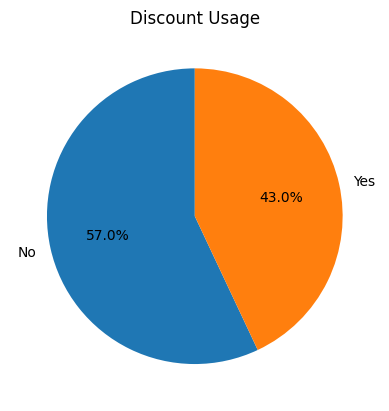

In [16]:
plt.figure()
df["Discount Applied"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Discount Usage")
plt.show()


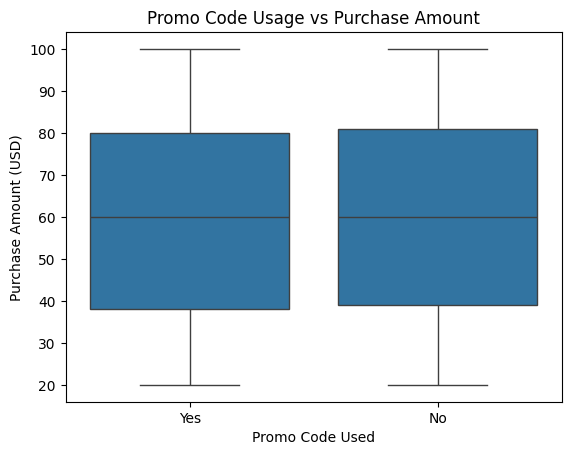

In [17]:
plt.figure()
sns.boxplot(
    x="Promo Code Used",
    y="Purchase Amount (USD)",
    data=df
)
plt.title("Promo Code Usage vs Purchase Amount")
plt.show()


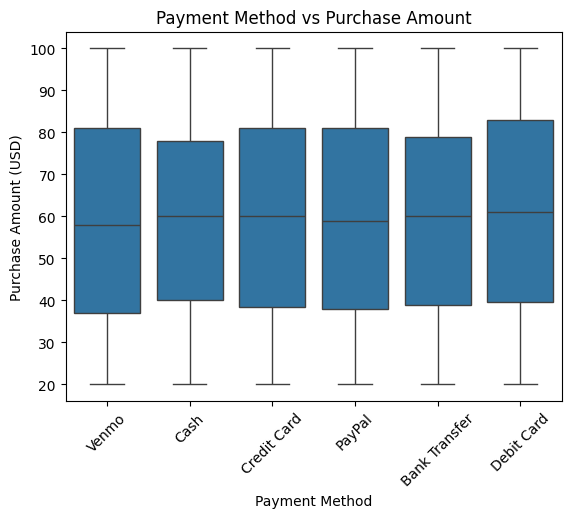

In [18]:
plt.figure()
sns.boxplot(
    x="Payment Method",
    y="Purchase Amount (USD)",
    data=df
)
plt.title("Payment Method vs Purchase Amount")
plt.xticks(rotation=45)
plt.show()


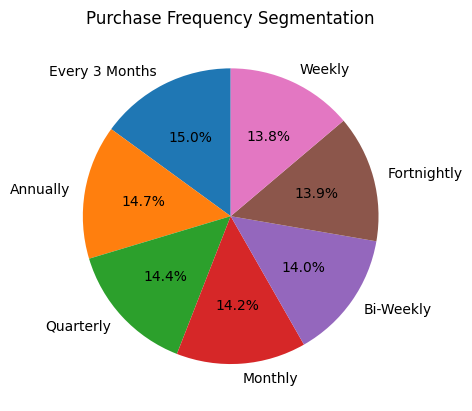

In [19]:
plt.figure()
df["Frequency of Purchases"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Purchase Frequency Segmentation")
plt.show()


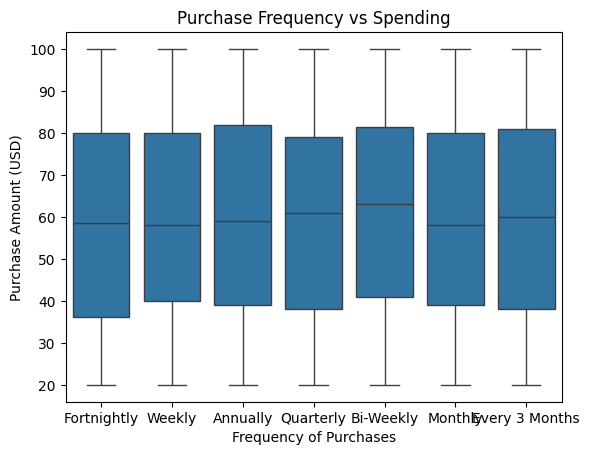

In [20]:
plt.figure()
sns.boxplot(
    x="Frequency of Purchases",
    y="Purchase Amount (USD)",
    data=df
)
plt.title("Purchase Frequency vs Spending")
plt.show()


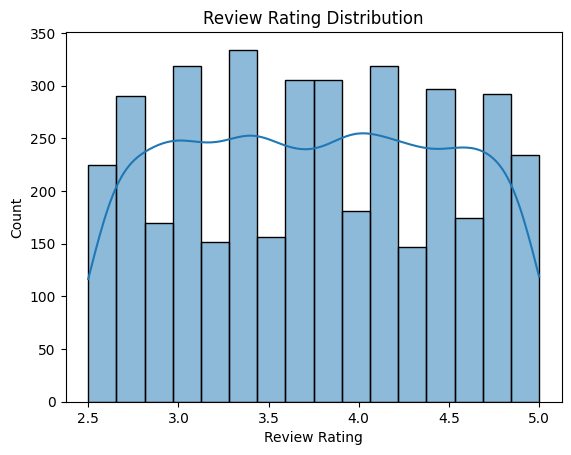

In [21]:
plt.figure()
sns.histplot(df["Review Rating"], kde=True)
plt.title("Review Rating Distribution")
plt.show()

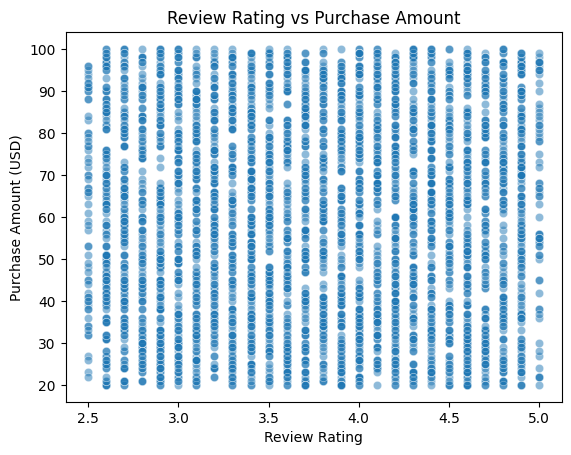

In [22]:
plt.figure()
sns.scatterplot(
    x="Review Rating",
    y="Purchase Amount (USD)",
    data=df,
    alpha=0.5
)
plt.title("Review Rating vs Purchase Amount")
plt.show()


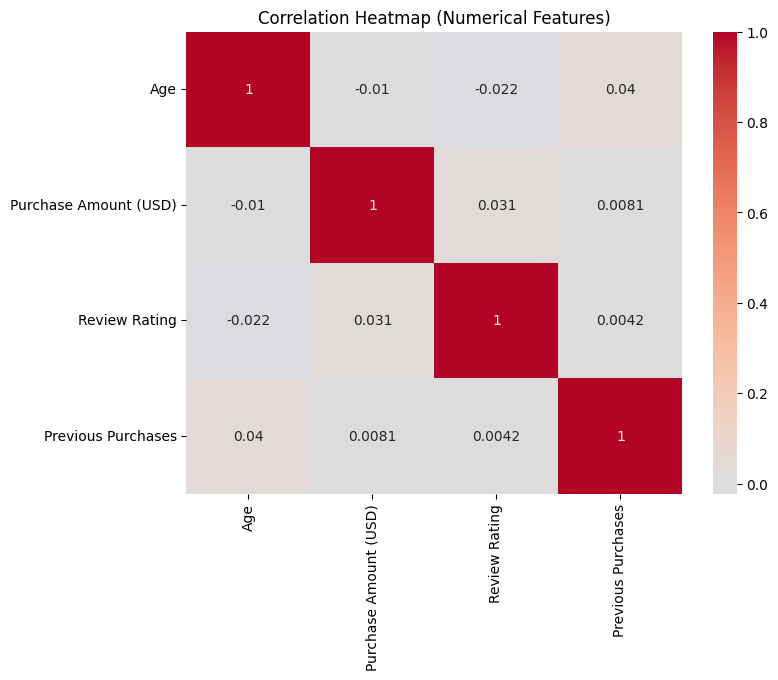

In [23]:
numeric_cols = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

plt.figure(figsize=(8,6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


In [24]:
df["customer_value_score"] = (
    df["Purchase Amount (USD)"] * 0.4 +
    df["Previous Purchases"] * 1.5 +
    df["Review Rating"] * 10
)


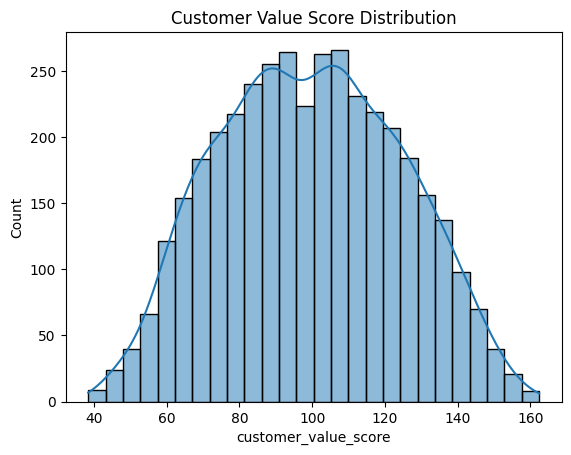

In [25]:
plt.figure()
sns.histplot(df["customer_value_score"], kde=True)
plt.title("Customer Value Score Distribution")
plt.show()
